# **필요한 라이브러리 불러오기**

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
from torchvision.transforms.functional import to_pil_image
import torch.nn.functional as F

# **MNIST 데이터셋 불러오기**
- 60,000개의 train data, 10,000개의 test data

In [ ]:
# GPU로 연산.
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# 랜덤 시드 고정.
# 실험 조건을 동일하게 설정하여,
# 같은 input을 넣으면 같은 결과가 나올 수 있도록 함.
torch.manual_seed(777)
if device == 'cuda':
    torch.cuda.manual_seed_all(777)

In [ ]:
# MNIST dataset
# 60,000개의 train data, 10,000개의 test data
mnist_train = torchvision.datasets.MNIST(root='MNIST_data/', # 다운로드 경로 지정
                          train=True, # True를 지정하면 훈련 데이터로 다운로드
                          transform=transforms.ToTensor(), # 텐서로 변환
                          download=True)

mnist_test = torchvision.datasets.MNIST(root='MNIST_data/', # 다운로드 경로 지정
                         train=False, # False를 지정하면 테스트 데이터로 다운로드
                         transform=transforms.ToTensor(), # 텐서로 변환
                         download=True)

100%|██████████| 9912422/9912422 [00:00<00:00, 203496264.17it/s]

Extracting MNIST_data/MNIST/raw/train-images-idx3-ubyte.gz to MNIST_data/MNIST/raw


100%|██████████| 28881/28881 [00:00<00:00, 110323947.02it/s]


Extracting MNIST_data/MNIST/raw/train-labels-idx1-ubyte.gz to MNIST_data/MNIST/raw



100%|██████████| 1648877/1648877 [00:00<00:00, 80724281.82it/s]

Extracting MNIST_data/MNIST/raw/t10k-images-idx3-ubyte.gz to MNIST_data/MNIST/raw




100%|██████████| 4542/4542 [00:00<00:00, 23346236.24it/s]


Extracting MNIST_data/MNIST/raw/t10k-labels-idx1-ubyte.gz to MNIST_data/MNIST/raw



In [ ]:
# dataset 크기 출력
print(len(mnist_train))
print(len(mnist_test))

60000
10000


# **Data Augmentation**

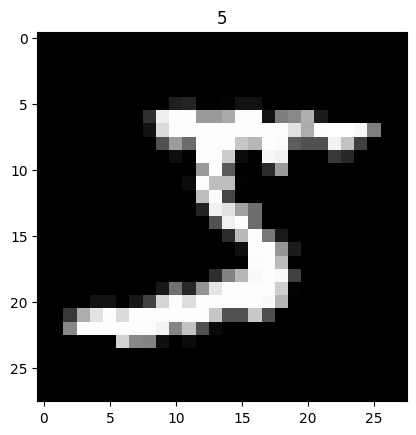

In [ ]:
# random affine 적용후 데이터 시각화
plt.imshow(torchvision.transforms.RandomAffine((10,30))(to_pil_image(mnist_train.data[0])), cmap='gray')
plt.title('%s' % mnist_train[0][1])
plt.show()

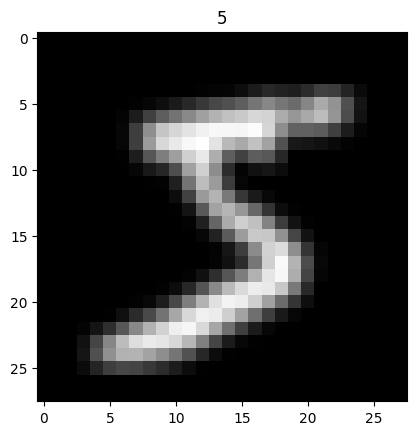

In [ ]:
# blur 적용후 데이터 시각화
plt.imshow(transforms.GaussianBlur(kernel_size=3)(to_pil_image(mnist_train.data[0])), cmap='gray')
plt.title('%s' % mnist_train[0][1])
plt.show()

## ✏️ TODO: Data Augmentation 적용하기

아래 코드의 빈칸을 채워 MNIST 학습 데이터에 **두 가지 Data Augmentation**을 적용해 보세요.

- 각 매개변수와 일치하는 augmentation 이름을 작성하세요.
- `degrees`에 최소 회전 각도와 최대 회전 각도를 작성하세요.
- 빈칸을 모두 채운 후 셀을 실행하여 데이터셋을 생성하세요.

In [ ]:
#  Random Affinement, GaussianBlur을 적용한 버전의 데이터셋 다운로드

#  GaussianBlur : 이미지에 가우시안 블러를 적용합니다.
#  RandomAffine : 이미지를 회전, 이동, 확대·축소하거나 기울입니다.

# 기존 매개변수를 확인하고 적용할 augmentation 이름 2가지를 작성하세요.
# degrees=(최소 회전 각도, 최대 회전 각도)
# 첫 번째 빈칸에는 회전 범위의 최솟값을 작성하세요.
# 두 번째 빈칸에는 회전 범위의 최댓값을 작성하세요.

train_transforms = transforms.Compose(
        [transforms.________(degrees=(____, ____)),
         transforms.________(kernel_size=3),
         transforms.ToTensor()
        ])

augmented_data = torchvision.datasets.MNIST(root='MNIST_data/',
                                        train=True,
                                        transform=train_transforms,
                                        download=True)

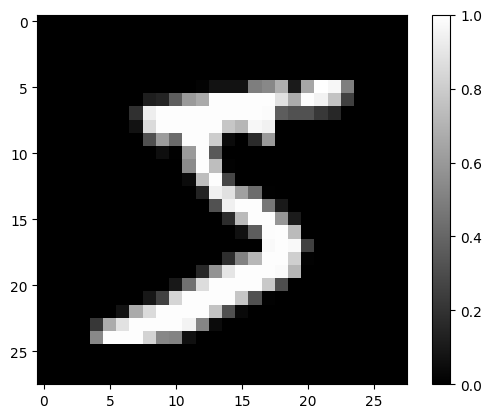

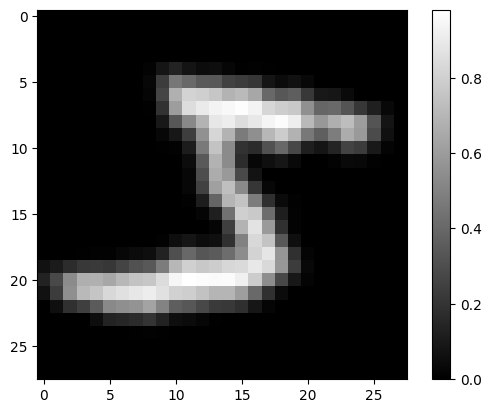

In [ ]:
# original 이미지와 augmented 이미지 비교

im = mnist_train[0][0][0]
aug_im = augmented_data[0][0][0]

# Normal image
plt.imshow(im, cmap="gray")
plt.colorbar()
plt.show()

# Agumented image
plt.imshow(aug_im, cmap="gray")
plt.colorbar()
plt.show()

In [ ]:
# augmented_data의 일부만 사용
idx = range(0,20000)
train_subset = torch.utils.data.Subset(augmented_data, idx)

# original dataset과 합친 dataset 생성
train_dataset = torch.utils.data.ConcatDataset([train_subset,mnist_train])

# 합쳐진 dataset 크기 출력
print(len(train_dataset))

80000


## ✏️ TODO: Batch Size에 따른 학습 성능 비교하기

`batch_size`를 서로 다른 값으로 변경하면서 모델을 여러 번 학습해 보세요.

- 예시: `32`, `64`, `128`, `256`
- 실험할 때는 batch size를 제외한 epoch, learning rate 등의 조건을 동일하게 유지하세요.
- batch size를 변경할 때마다 DataLoader를 다시 생성하고 모델을 처음부터 학습하세요.
- 각 실험의 학습 시간, loss 및 테스트 정확도를 기록하여 성능을 비교하세요.

In [ ]:
# 비교 실험에 사용할 batch size를 작성하세요.
batch_size = ____

# Data loader를 사용하여 배치 크기 지정
train_loader=torch.utils.data.DataLoader(train_dataset,
                                        batch_size=batch_size,
                                        shuffle=True)
test_loader = torch.utils.data.DataLoader(mnist_test,
                                          batch_size=batch_size,
                                          shuffle=False)

# **모델 설계**
- MLP witih dropout

## ✏️ TODO: Dropout 비율 설정하기

아래 코드의 빈칸에 학습 과정에서 무작위로 비활성화할 뉴런의 비율을 작성하세요.

- Dropout 비율은 `0`부터 `1` 사이의 값으로 설정합니다.
- 값이 클수록 학습 중 더 많은 뉴런이 비활성화됩니다.
- 서로 다른 Dropout 비율로 모델을 학습한 후 loss와 테스트 정확도를 비교해 보세요.
- Dropout을 적용하지 않은 모델과 비교하여 과적합이 어떻게 달라지는지 확인해 보세요.

In [ ]:
class Net(nn.Module):
    def __init__(self):
        super(Net,self).__init__()
        # input_layer = 28*28, hidden_layer1 = 512
        self.fc1 = nn.Linear(28*28, 512)
        # hidden_layer1 = 512, hidden_layer2 = 512
        self.fc2 = nn.Linear(512,512)
        # hidden_layer2 = 512, output_layer = 10
        self.fc3 = nn.Linear(512,10)

        # 학습 과정에서 무작위로 비활성화할 뉴런의 비율을 작성하세요.
        # 0부터 1 사이의 값으로 설정하며, 값이 클수록 더 많은 뉴런이 비활성화됩니다.
        self.dropout = nn.Dropout(____)

    def forward(self,x):
        x = x.view(-1,28*28)  # flatten
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)

        return x

In [ ]:
model = Net().to(device)   # GPU에서 연산 수행하기 위해 device로 보냄

# **Train**

In [ ]:
epochs = 15             # 학습 횟수
learning_rate = 0.01    # 학습률

In [ ]:
# cost function과 optimizer 정의
criterion = nn.CrossEntropyLoss().to(device)
optimizer = torch.optim.SGD(model.parameters(),lr=learning_rate)

In [ ]:
# 모델 학습
model.train()
loss_list = []

for epoch in range(epochs):
  avg_loss = 0.0
  total_loss = 0.0
  for iter, data in enumerate(train_loader):

    # gradient 초기화
    optimizer.zero_grad()

    images, labels = data
    images = images.to(device)
    labels = labels.to(device)

    # 모델에 이미지 입력
    output = model(images)
    loss = criterion(output,labels)

    # 파라미터 업데이트
    loss.backward()
    optimizer.step()

    # 손실값 기록
    avg_loss += loss.item()
    total_loss += loss.item()

    if (iter+1) % 100==0: #100으로 나누어지는 순번일 경우
      print('Train Epoch: {} [{}/{}]\tLoss: {:.5f}'.format(
      epoch, iter+1, len(train_loader), avg_loss/100.)) # 케이스 100개 마다 평균 loss 출력
      avg_loss = 0.0 # 누적 loss 값 초기화
  loss_list.append(total_loss/(iter+1))  # epoch마다 평균 loss를 loss_list에 추가
print('\nLearning finished!')

Train Epoch: 0 [100/625]	Loss: 2.28083


In [ ]:
# # weights 다운로드
# !pip install gdown
!gdown --id 1eqC3zwCImM4cgFf8jFMXSvZPCYG0Bdop

Downloading...
From: https://drive.google.com/uc?id=1eqC3zwCImM4cgFf8jFMXSvZPCYG0Bdop
To: /content/overfitting_Weights.pth
100% 2.68M/2.68M [00:00<00:00, 235MB/s]


# **Test**

In [ ]:
## weights를 load
model.load_state_dict(torch.load('/content/overfitting_Weights.pth'))

<All keys matched successfully>

In [ ]:
# 모델 성능 확인
with torch.no_grad(): # torch.no_grad(): gradient 계산을 수행하지 않음
  model.eval()
  accuracy = 0.0

  for iter, data in enumerate(test_loader):
    images, labels = data
    images = images.to(device)
    labels = labels.to(device)
    output = model(images)
    pred = torch.argmax(output,1) == labels
    accuracy += pred.float().sum() # 케이스 100개 마다 평균 loss 출력

  print("Accuracy : {:.2f}%".format(100*accuracy/len(mnist_test))) #epoch마다 vudrbs loss를 loss_list에 추가

Accuracy : 94.00%
